# Naive bayes classifier: Google Play Store reviews

## 1. Data Loading

In [ ]:
# Handle import up-front
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statistics import mean 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

from utils import cross_val

### 1.1. Load the data

In [2]:
# Load the data from the URL provided in the project tutorial
data_df=pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv')

### 1.2. Inspect the data

In [3]:
data_df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   package_name  891 non-null    object
 1   review        891 non-null    object
 2   polarity      891 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.0+ KB


### 1.3. Train-test split

In [5]:
# Separate features from labels
labels=data_df['polarity']
features=data_df.drop('polarity', axis=1)

# Split the data into training and testing features and labels
training_features, testing_features, training_labels, testing_labels=train_test_split(
    features,
    labels,
    test_size=0.25,
    random_state=315
)

### 1.4. Data encoding

In [6]:
# Get just the reviews from the training data
training_reviews=training_features['review']

# Fit the vectorizer and transform the training reviews into word counts
vector_model=CountVectorizer(stop_words="english")
training_word_counts=vector_model.fit_transform(training_reviews).toarray()

print(f'Word count matrix has {training_word_counts.shape[0]} rows and {training_word_counts.shape[1]} columns')

Word count matrix has 668 rows and 3151 columns


In [7]:
feature_names=vector_model.get_feature_names_out()
training_word_counts=pd.DataFrame(training_word_counts, columns=feature_names)
training_word_counts.head()

,000,04,0x,10,100,101,11,113mb,1186,12,...,śŕ,şŕ,šŕ,šŕľ,źŕ,żŕ,żŕľ,žŕ,žŕľ,ˇŕ
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
word_counts=training_word_counts.sum().tolist()

## 2. EDA

### 2.1. Baseline model performance

In [9]:
# Define the model
model=MultinomialNB()

# Cross-validate the model
scores=cross_val(model, training_word_counts, training_labels)

Cross-validation accuracy: 80.99 +/- 4.17%


### 2.2. Review length distribution

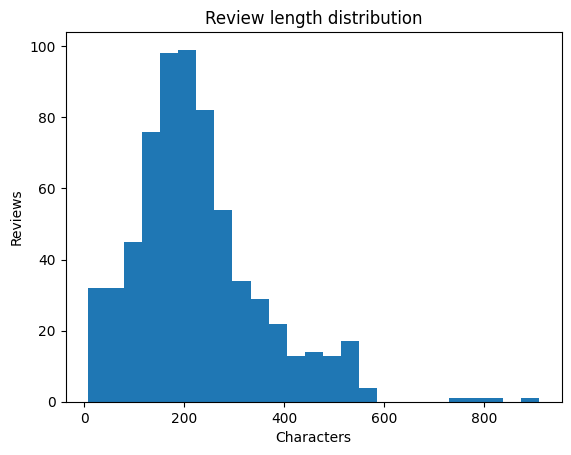

Review length mean: 227
Review length min: 8
Review length max: 910


In [10]:
# Try plotting the distribution of review lengths!

# Get the lengths (in characters)
lengths=training_features['review'].str.len().tolist()

plt.title('Review length distribution')
plt.xlabel('Characters')
plt.ylabel('Reviews')
plt.hist(lengths, bins=25)
plt.show()

print(f'Review length mean: {mean(lengths):.0f}')
print(f'Review length min: {min(lengths):.0f}')
print(f'Review length max: {max(lengths):.0f}')

### 2.3. Long reviews

In [11]:
training_features['review_length']=lengths
long_reviews=training_features[training_features['review_length'] > 800]

In [12]:
print(long_reviews['review'].iloc[0])

  ătoo slow loading webclips!!! ăno pdf support at all... (even simpler apps do that!) ă web pages that are clipped do not adjust to current window size automatically when window is shrunk or expanded, (any program does this...geez). ă highlighting? needs more colors instead of brown mustard yellow. no customer support responses either, evernote must have been taken over by students. it's not even fun to use anymore because it is slow as hell.  this is especially for serious business users. any five star ratings down here must have been given by employees under different themes. this program has really retarded over the years. they need to stick to improving their bread and butter instead of selling side junk and features that are useless. well they got my money this time, so i have to put up with it for a few more months. the lack of pdf support really is terrible for a program like this.


In [13]:
print(long_reviews['review'].iloc[1])

 bait and switch i purchased my 3rd samsung tablet with  advertisement of free gifts, one of them being 48 additional gb cloud storage for 2 years.  the 2nd samsung tablet i bought also had this free gift and it was a nightmare to get samsung and dropbox to honor it.  so, after buying this 3rd high end tablet with the same claim of the free 48gb for 2 years in the fine print, which you can only see after purchasing the tablet, dropbox only honors the offer on the first device you purchased and you are disqualified for all future devices.  this is sleazy and bait and switch.  free= not subject to any compensation, encumbrance, repayment in kind, etc.  because of this bait and switch advertising on the part of samsung and dropbox i suggest you really find out what kind of company dropbox is before using their services.


### 2.4. Short reviews

In [23]:
short_length=25

short_reviews=training_features[training_features['review_length'] < short_length]
short_reviews.head()


,package_name,review,review_length
755,com.shirantech.kantipur,too much pop up add,21
761,com.shirantech.kantipur,aa nice,8
851,com.hamropatro,very useful !,15
843,com.hamropatro,superb! all in one!,20
846,com.hamropatro,nice app,10


### 2.3. Feature selection

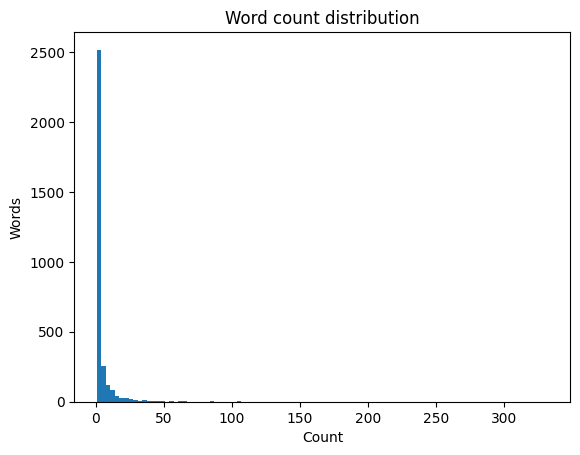

In [21]:
# After encoding we have over three thousand features - do we need all of them? Try plotting the distribution of word counts!

plt.title('Word count distribution')
plt.xlabel('Count')
plt.ylabel('Words')
plt.hist(word_counts, bins=100)
plt.show()


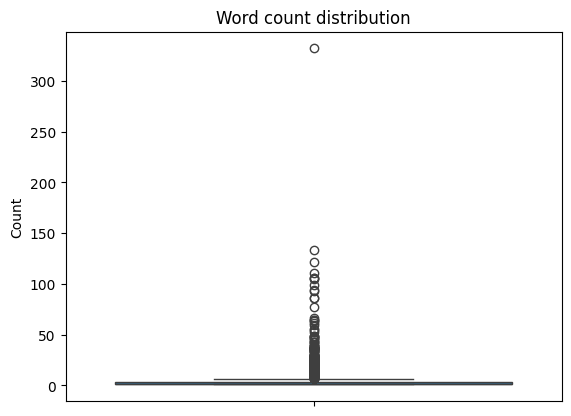

In [22]:
plt.title('Word count distribution')
plt.ylabel('Count')
sns.boxplot(word_counts)
plt.show()

## 3. Model training

In [ ]:
# Your code here...

## 4. Model optimization

In [ ]:
# For this project we will compare the three types of naive bayes models avalible in Scikit-learn: GaussianNB, MultinomialNB or BernoulliNB, rather than running hyperparameter optimization. Also, feel free to experiment and try any other tricks or methods you can find via research or come up with yourself to improve model performance!

# Your code here...

## 5. Final model evaluation